In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD

In [3]:
print("Downloading dataset via KaggleHub...")
dataset_path = kagglehub.dataset_download("moazeldsokyx/dogs-vs-cats")
print(f"Dataset downloaded to: {dataset_path}")

Using Colab cache for faster access to the 'dogs-vs-cats' dataset.
Dataset downloaded to: /kaggle/input/dogs-vs-cats


In [4]:
def find_data_directories(root_path):
    train_dir = None
    test_dir = None
    for root, dirs, files in os.walk(root_path):
        if 'cats' in dirs and 'dogs' in dirs:
            parent_name = os.path.basename(root).lower()
            if 'test' in parent_name:
                test_dir = root
            else:
                train_dir = root
    return train_dir, test_dir

In [5]:
TRAIN_DIR, TEST_DIR = find_data_directories(dataset_path)

if not TRAIN_DIR:
    raise FileNotFoundError("Critical Error: Could not automatically locate the training data.")

print(f"Training Directory: {TRAIN_DIR}")
print(f"Testing Directory:  {TEST_DIR}")

Training Directory: /kaggle/input/dogs-vs-cats/dataset/train
Testing Directory:  /kaggle/input/dogs-vs-cats/dataset/test


In [6]:
IMG_WIDTH, IMG_HEIGHT = 150, 150
BATCH_SIZE = 32

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 if TEST_DIR is None else 0.0
)

In [8]:
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training' if TEST_DIR is None else None
)

Found 20000 images belonging to 2 classes.


In [9]:
val_source_dir = TEST_DIR if TEST_DIR else TRAIN_DIR
val_subset = None if TEST_DIR else 'validation'

validation_generator = test_datagen.flow_from_directory(
    val_source_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset=val_subset,
    shuffle=False
)

Found 12461 images belonging to 2 classes.


In [10]:
model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:

opt = SGD(learning_rate=0.001, momentum=0.9)

model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=15,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

model.save('cats_vs_dogs_model.keras')
print("Model saved as 'cats_vs_dogs_model.keras'")


--- Step 4: Training ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 267s 419ms/step - accuracy: 0.5450 - loss: 0.6877 - val_accuracy: 0.6187 - val_loss: 0.6506
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 262ms/step - accuracy: 0.5894 - loss: 0.6681 - val_accuracy: 0.5683 - val_loss: 0.6693
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 260ms/step - accuracy: 0.6056 - loss: 0.6510 - val_accuracy: 0.6380 - val_loss: 0.6257
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 262ms/step - accuracy: 0.6384 - loss: 0.6329 - val_accuracy: 0.6571 - val_loss: 0.6007
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 272ms/step - accuracy: 0.6657 - loss: 0.6112 - val_accuracy: 0.6967 - val_loss: 0.5678
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 261ms/step - accuracy: 0.6784 - loss: 0.5948 - val_accuracy: 0.7137 - val_loss: 0.5503
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.6932 - loss: 0.5820 - val_accuracy: 0.7441 - val_loss: 0.5184
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.7007 -


--- Step 5: Evaluation ---
390/390 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.7412 - loss: 0.5339
Final Validation Accuracy: 78.94%


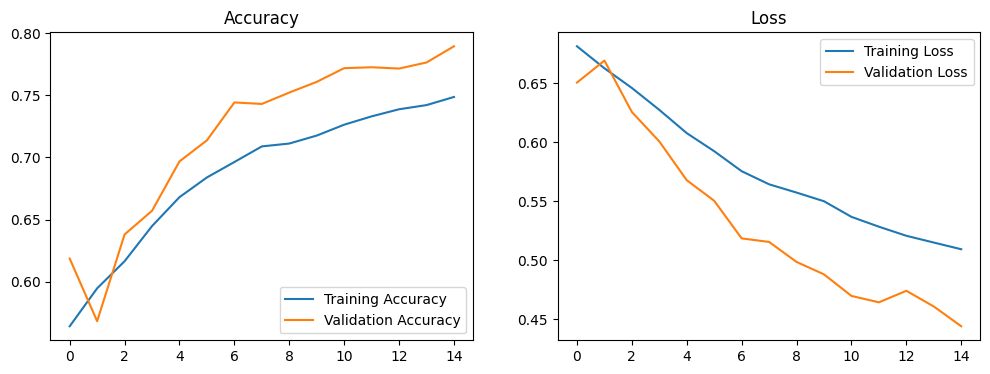

In [12]:

loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')
plt.show()

In [13]:

def predict_image(image_path):
    if not os.path.exists(image_path):
        print(f"Error: {image_path} not found")
        return

    img = load_img(image_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    labels = {v: k for k, v in train_generator.class_indices.items()}
    result_label = labels[class_idx]

    print(f"Prediction for {os.path.basename(image_path)}: {result_label.upper()} ({confidence:.2f}%)")

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{result_label.upper()} ({confidence:.1f}%)")
    plt.show()


--- Step 6: Prediction System ---


Demonstrating prediction on random training image: cat.2239.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediction for cat.2239.jpg: CATS (90.11%)


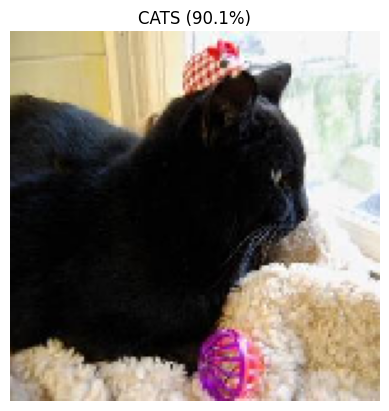

In [17]:
try:
    demo_cat_dir = os.path.join(TRAIN_DIR, 'cats')
    # Check if directory exists first to be safe
    if os.path.exists(demo_cat_dir):
        random_file = random.choice(os.listdir(demo_cat_dir))
        print(f"Demonstrating prediction on random training image: {random_file}")
        predict_image(os.path.join(demo_cat_dir, random_file))
    else:
        print("Demo directory not found.")
except Exception as e:
    print(f"Could not run demo prediction: {e}")